In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sbibm

from pyro_cases.run import train_and_test

In [3]:
device = torch.device("cuda:5")

In [4]:
sbibm.get_available_tasks()

['sir',
 'two_moons',
 'slcp',
 'gaussian_linear_uniform',
 'lotka_volterra',
 'bernoulli_glm',
 'gaussian_mixture',
 'gaussian_linear',
 'slcp_distractors',
 'bernoulli_glm_raw']

In [5]:
# torch.autograd.set_detect_anomaly(True)

In [6]:
out_dict = train_and_test(task_name="arm_earnings_latin_square_chr",
                          seed=123456,
                          device=device,
                          lr=1e-3,
                          lr_schedule="cosine_annealing",
                          num_particles=1,
                          vectorize_particles=False,
                          batch_size=1024,
                          network_width=1024,
                          steps=10_000,
                          direct_compare_n_obs=10,
                          k_hat_n_obs=30,
                          k_hat_n_samples=100,
                          vsbc_n_obs=1000,
                          show_progress=True,
                          return_vae=True)

100%|██████████| 10000/10000 [09:02<00:00, 18.43it/s]


[123456 completes] task start time: Fri Mar 28 20:18:15 2025; task end time: Fri Mar 28 20:28:47 2025; cost time: 631.4 seconds


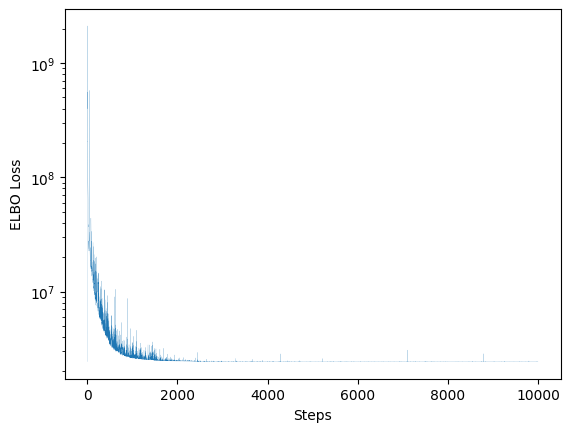

In [7]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("log")
plt.show()

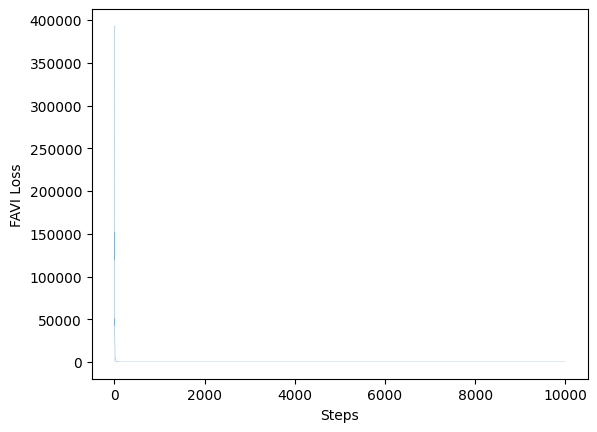

In [8]:
plt.plot(out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
# plt.yscale("log")
plt.show()

### K hat

In [9]:
print(out_dict["favi_k_hat"])
print(out_dict["elbo_k_hat"])

tensor([0.9138, 0.8771, 0.4580, 0.9403, 0.3182, 0.5006, 0.7334, 1.2570, 1.2184,
        0.6365, 0.6870, 0.4976, 0.6467, 1.0671, 0.7075, 1.1821, 0.9939, 0.7150,
        0.9655, 0.4496, 0.7246, 0.3501, 0.5429, 1.1498, 0.8314, 0.6277, 0.5874,
        0.4087, 1.1521, 0.5207], dtype=torch.float64)
tensor([1.2951, 1.0384, 0.7566, 0.7152, 1.2049, 0.9946, 1.7833, 0.7215, 1.2584,
        1.0092, 0.9991, 1.5426, 0.8113, 1.7373, 0.8781, 0.7301, 1.3536, 1.1586,
        1.2038, 1.4265, 1.0590, 1.3172, 1.9023, 0.8903, 1.9430, 1.2195, 0.5448,
        0.7456, 0.4180, 0.6233], dtype=torch.float64)


### VSBC

In [10]:
favi_vsbc = out_dict["favi_vsbc"]
elbo_vsbc = out_dict["elbo_vsbc"]

In [11]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

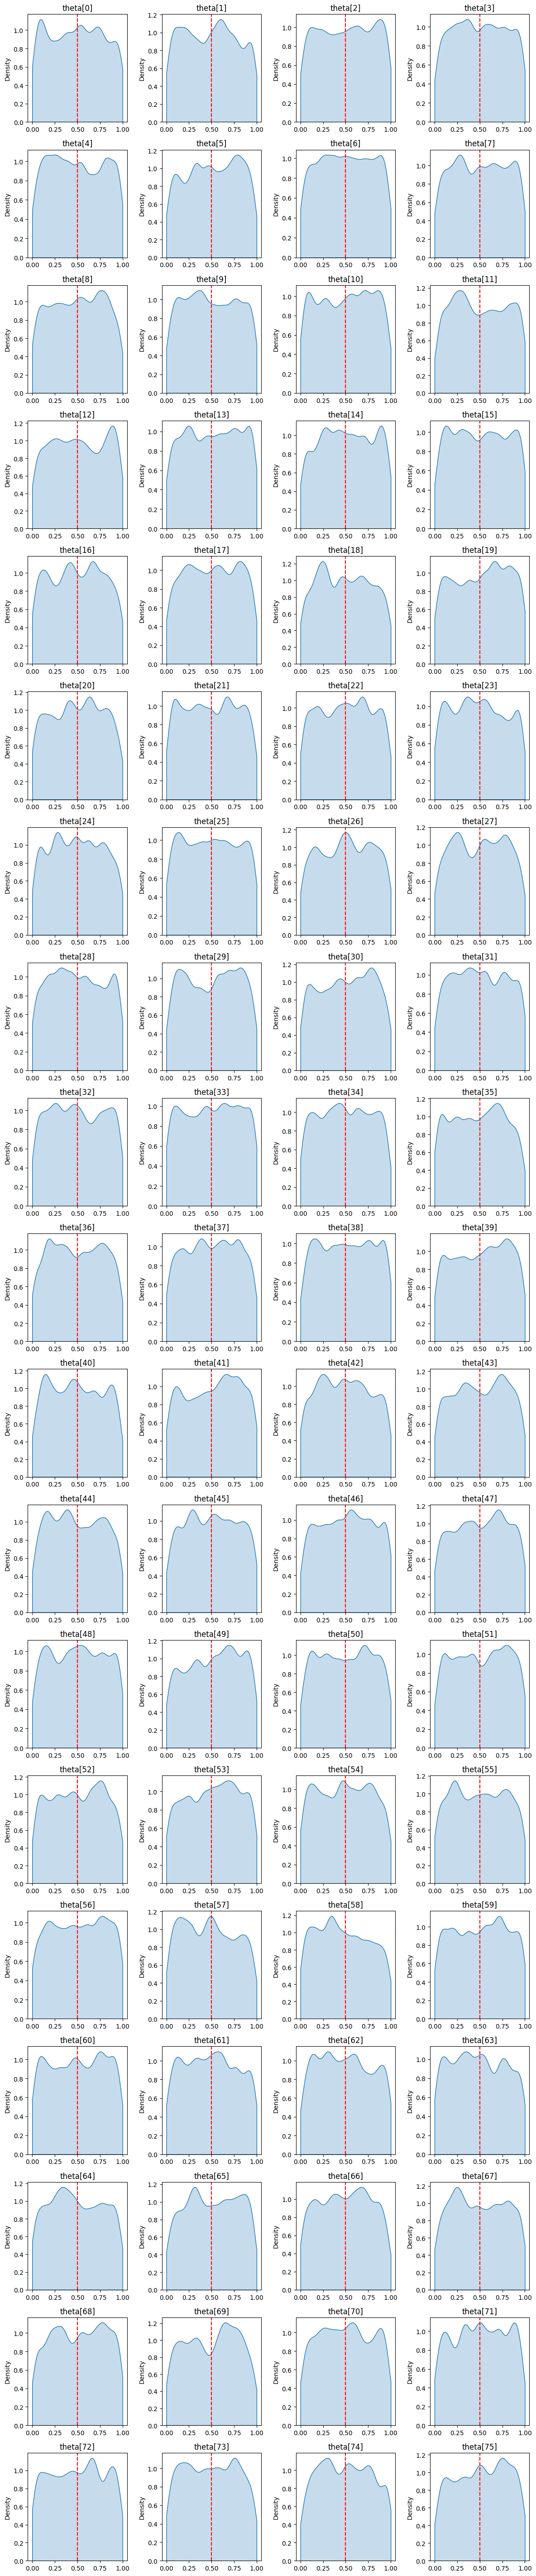

In [12]:
plot_vsbc(favi_vsbc)

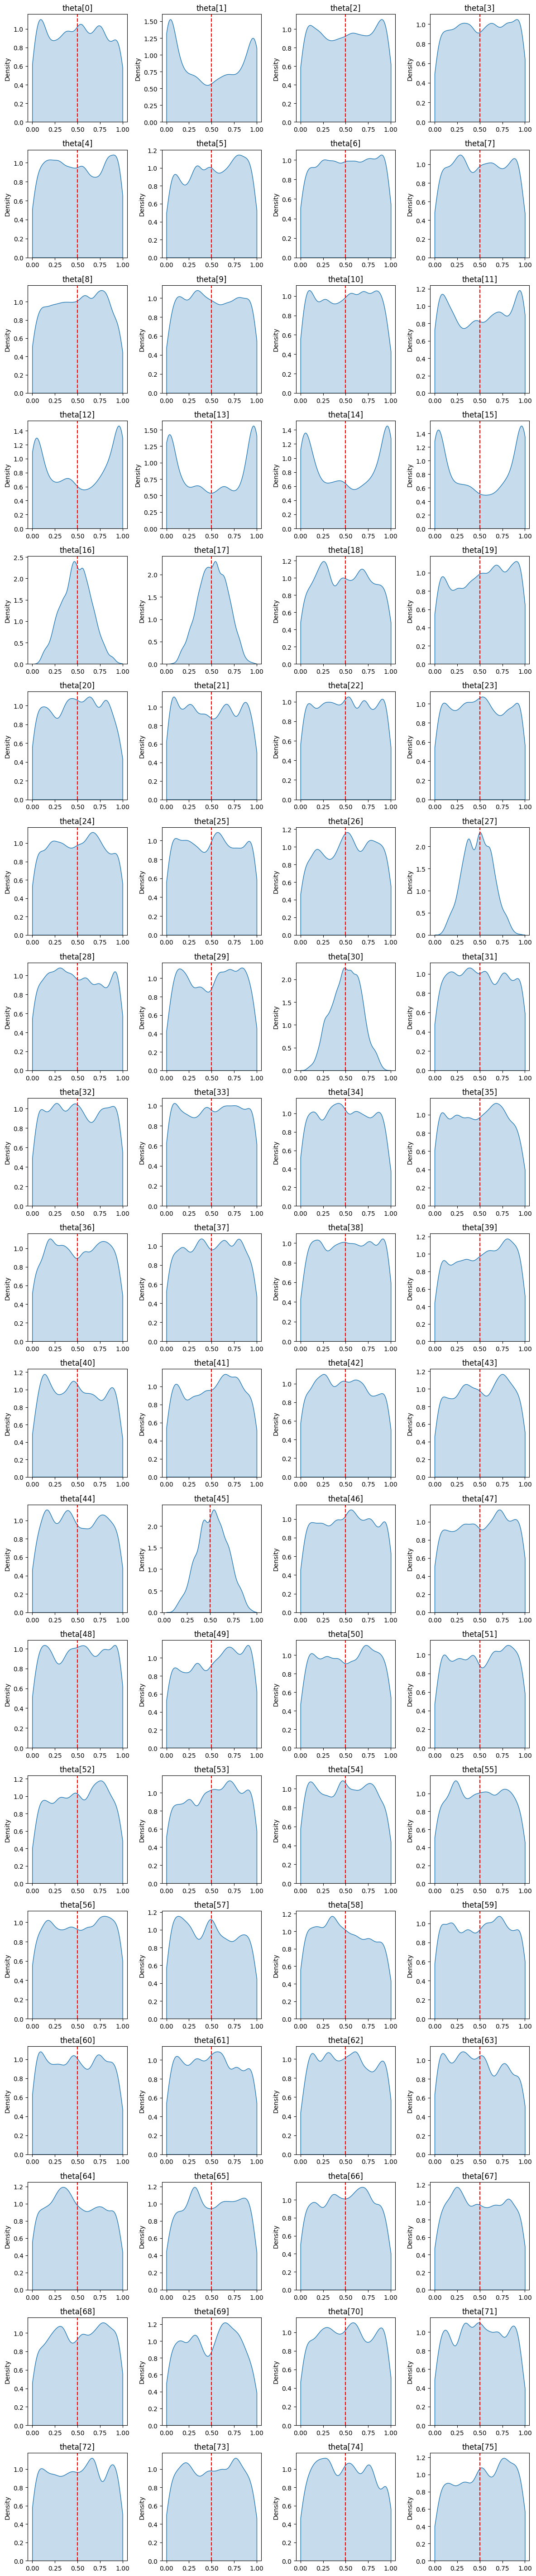

In [13]:
plot_vsbc(elbo_vsbc)

### Output

In [14]:
out_dict["elbo_test_dict_list"][0]["obs_seed"]

10000

In [15]:
out_dict["elbo_test_dict_list"][0]["obs"]

tensor([[ 2.6594e+02,  1.8431e+02,  2.0355e+02,  2.3494e+02,  2.1330e+02,
          1.7374e+02,  2.1837e+02,  2.1261e+02,  1.9318e+02,  1.6010e+02,
          2.2482e+02,  1.8957e+02,  1.8266e+02,  2.0742e+02,  2.3465e+02,
          2.2075e+02,  1.4121e+02,  2.2319e+02,  2.0653e+02,  2.6631e+02,
          1.9099e+02,  2.1069e+02,  2.1602e+02,  1.9740e+02,  1.6922e+02,
          1.5926e+02,  1.7300e+02,  2.1718e+02,  2.1196e+02,  1.9119e+02,
          2.5610e+02,  1.9684e+02,  2.3071e+02,  1.9297e+02,  2.0930e+02,
          1.5363e+02,  1.6846e+02,  1.8856e+02,  1.9614e+02,  1.5598e+02,
          2.1835e+02,  2.0659e+02,  2.3971e+02,  1.9054e+02,  1.7640e+02,
          1.5706e+02,  1.7578e+02,  1.5947e+02,  2.2396e+02,  2.5409e+02,
          1.9332e+02,  2.3098e+02,  2.0136e+02,  1.8018e+02,  1.9432e+02,
          2.0512e+02,  2.1407e+02,  2.1749e+02,  2.0750e+02,  1.4101e+02,
          2.0309e+02,  1.8704e+02,  2.2135e+02,  1.8210e+02,  1.6615e+02,
          1.5562e+02,  2.0719e+02,  2.

In [16]:
out_dict["elbo_test_dict_list"][0]["true_theta"]

tensor([-1.0830,  0.9904, -0.6998,  0.3377,  1.5405, -1.2485, -0.4260,  0.8713,
         0.2994,  0.6963,  0.4804,  0.1174, -1.1855,  0.0495, -0.2240,  0.5813,
         3.1550, -0.1846, -0.6495, -0.6012,  1.1667, -0.4354,  1.6454, -0.4419,
        -0.5369,  0.8649, -0.3210, -2.0408,  0.0397, -1.5246, -0.6212,  0.5096,
        -0.9852, -0.0234, -0.6514, -0.2427,  0.3966, -0.3853,  0.2614, -0.0745,
        -1.3859,  0.1785,  0.0193, -0.3340,  0.2959,  0.6902,  0.7676,  1.5194,
        -0.8573, -1.4565,  0.2990, -1.1067,  0.9228,  0.4171, -1.0943,  0.6741,
        -1.0072, -0.9045,  0.1697,  0.0127, -1.1115, -0.8249, -0.1897,  0.5360,
         0.4014, -0.2636,  1.4708, -1.0315, -0.3318, -0.0704,  1.3309,  0.3370,
        -0.2997, -0.5159,  0.8499,  0.0096])

In [17]:
out_dict["elbo_test_dict_list"][0]["est_mu"]

tensor([ 2.3699e-02,  6.2815e-01,  8.6859e-03,  1.1218e-01,  5.8769e-02,
         2.5090e-02,  5.4788e-02, -2.3327e-02, -8.8321e-03,  7.1176e-03,
         9.2223e-05,  6.1136e-01, -1.2101e-01,  2.1153e-01, -1.1100e-01,
         9.1003e-02, -6.6825e-02,  7.4580e-02, -1.3525e-02,  1.6934e-02,
        -1.3351e-02,  1.0309e-02,  1.6685e-02,  5.2488e-02,  3.2435e-02,
         2.7795e-02,  3.2511e-02, -9.5520e-02,  1.7923e-02,  3.7918e-02,
         1.8337e-02, -2.6025e-03,  1.4049e-02, -2.5335e-02, -5.2099e-02,
         3.6477e-03,  1.3750e-02, -2.4788e-02, -1.6952e-02,  4.6647e-02,
        -1.9784e-02, -1.9767e-02, -2.6975e-03, -8.3578e-03,  1.4760e-02,
         1.5237e-01, -1.1090e-02,  2.1281e-04,  1.0635e-03,  3.9565e-03,
         4.2977e-02,  2.4877e-02,  6.2304e-02, -1.0220e-02, -5.4244e-03,
        -1.3767e-02, -2.1090e-02,  1.2050e-03,  3.2946e-02, -4.2744e-02,
        -3.6740e-02, -1.2317e-02,  4.6576e-02, -7.0868e-03, -1.3896e-02,
        -3.0922e-04, -1.4815e-02, -1.5376e-02,  2.1

In [18]:
out_dict["elbo_test_dict_list"][0]["est_sigma2"]

tensor([1.0557, 0.0697, 0.9438, 0.9577, 0.9751, 0.9649, 1.0092, 1.0779, 1.0302,
        0.9859, 1.1191, 0.2781, 0.2948, 0.2892, 0.2965, 0.2896, 5.0000, 5.0000,
        1.0204, 0.9635, 1.0291, 0.9512, 0.9683, 0.9851, 1.0230, 0.9489, 1.0083,
        5.0000, 0.9759, 1.0837, 5.0000, 1.0115, 1.0268, 1.0325, 1.0593, 1.0429,
        1.0002, 1.0118, 1.0664, 1.0185, 1.0008, 1.0169, 1.0109, 1.0209, 0.9743,
        5.0000, 0.9801, 0.9501, 0.9665, 0.9139, 0.9722, 1.0211, 1.0592, 0.9845,
        1.0358, 1.0209, 0.9785, 0.9598, 1.0077, 1.0084, 1.0035, 1.0192, 1.0888,
        0.9926, 1.0456, 1.0183, 1.0518, 1.0679, 0.9958, 1.0733, 1.0158, 1.0863,
        1.0449, 0.9511, 0.9642, 1.0066])

In [19]:
out_dict["favi_test_dict_list"][0]["obs_seed"]

10000

In [20]:
out_dict["favi_test_dict_list"][0]["obs"]

tensor([[ 2.6594e+02,  1.8431e+02,  2.0355e+02,  2.3494e+02,  2.1330e+02,
          1.7374e+02,  2.1837e+02,  2.1261e+02,  1.9318e+02,  1.6010e+02,
          2.2482e+02,  1.8957e+02,  1.8266e+02,  2.0742e+02,  2.3465e+02,
          2.2075e+02,  1.4121e+02,  2.2319e+02,  2.0653e+02,  2.6631e+02,
          1.9099e+02,  2.1069e+02,  2.1602e+02,  1.9740e+02,  1.6922e+02,
          1.5926e+02,  1.7300e+02,  2.1718e+02,  2.1196e+02,  1.9119e+02,
          2.5610e+02,  1.9684e+02,  2.3071e+02,  1.9297e+02,  2.0930e+02,
          1.5363e+02,  1.6846e+02,  1.8856e+02,  1.9614e+02,  1.5598e+02,
          2.1835e+02,  2.0659e+02,  2.3971e+02,  1.9054e+02,  1.7640e+02,
          1.5706e+02,  1.7578e+02,  1.5947e+02,  2.2396e+02,  2.5409e+02,
          1.9332e+02,  2.3098e+02,  2.0136e+02,  1.8018e+02,  1.9432e+02,
          2.0512e+02,  2.1407e+02,  2.1749e+02,  2.0750e+02,  1.4101e+02,
          2.0309e+02,  1.8704e+02,  2.2135e+02,  1.8210e+02,  1.6615e+02,
          1.5562e+02,  2.0719e+02,  2.

In [21]:
out_dict["favi_test_dict_list"][0]["true_theta"]

tensor([-1.0830,  0.9904, -0.6998,  0.3377,  1.5405, -1.2485, -0.4260,  0.8713,
         0.2994,  0.6963,  0.4804,  0.1174, -1.1855,  0.0495, -0.2240,  0.5813,
         3.1550, -0.1846, -0.6495, -0.6012,  1.1667, -0.4354,  1.6454, -0.4419,
        -0.5369,  0.8649, -0.3210, -2.0408,  0.0397, -1.5246, -0.6212,  0.5096,
        -0.9852, -0.0234, -0.6514, -0.2427,  0.3966, -0.3853,  0.2614, -0.0745,
        -1.3859,  0.1785,  0.0193, -0.3340,  0.2959,  0.6902,  0.7676,  1.5194,
        -0.8573, -1.4565,  0.2990, -1.1067,  0.9228,  0.4171, -1.0943,  0.6741,
        -1.0072, -0.9045,  0.1697,  0.0127, -1.1115, -0.8249, -0.1897,  0.5360,
         0.4014, -0.2636,  1.4708, -1.0315, -0.3318, -0.0704,  1.3309,  0.3370,
        -0.2997, -0.5159,  0.8499,  0.0096])

In [22]:
out_dict["favi_test_dict_list"][0]["est_mu"]

tensor([ 1.6099e-02,  7.9335e-01,  2.3912e-02,  8.3540e-02, -2.1915e-03,
         7.2076e-03,  1.2352e-02, -8.4612e-03,  9.9953e-03,  1.9651e-03,
         1.4628e-02,  4.2071e-01, -7.4273e-01,  3.3374e-01,  1.0865e-01,
         6.6797e-01,  3.9940e-02,  7.0083e-02,  5.9734e-03, -1.0759e-01,
         1.5707e-02,  2.0293e-01,  2.7066e-01,  1.3954e-02, -4.4824e-01,
         5.5588e-02, -4.1070e-03,  3.9936e-03,  2.7753e-03, -1.8170e-04,
         1.0604e-03,  7.1884e-03, -4.2006e-03, -2.0984e-03, -4.4478e-03,
         1.7312e-04, -3.9082e-03, -3.4026e-03,  2.7128e-03,  2.2307e-05,
         6.6404e-04,  3.5188e-03, -3.4762e-03, -6.9719e-03, -2.1864e-03,
        -1.7629e-03,  2.0391e-03, -5.0701e-04, -1.0499e-03,  1.3928e-03,
         4.5359e-03,  8.8023e-03,  1.7647e-02, -4.6106e-03, -1.1462e-02,
        -2.7583e-03,  8.4727e-03, -8.4224e-03, -1.2387e-03, -1.3917e-02,
         1.6979e-03,  3.3288e-03,  4.9332e-04, -2.1210e-03, -7.9058e-03,
         4.6084e-03,  6.5700e-03,  5.8782e-03,  2.1

In [23]:
out_dict["favi_test_dict_list"][0]["est_sigma2"]

tensor([1.0031, 0.1950, 0.9974, 1.0040, 1.0106, 0.9963, 1.0015, 1.0058, 1.0150,
        1.0134, 1.0106, 0.1936, 0.2053, 0.1957, 0.2028, 0.1957, 1.0013, 1.0009,
        1.0031, 0.9691, 1.0103, 0.9562, 0.9478, 0.9773, 0.4219, 0.9633, 1.0075,
        1.0000, 1.0132, 1.0106, 1.0210, 1.0013, 1.0079, 1.0086, 1.0062, 1.0135,
        1.0150, 0.9967, 1.0075, 1.0016, 1.0004, 1.0126, 1.0001, 1.0070, 1.0032,
        1.0099, 1.0108, 1.0131, 1.0184, 1.0187, 1.0016, 1.0186, 1.0085, 1.0106,
        1.0091, 1.0130, 1.0055, 1.0077, 0.9987, 1.0168, 1.0076, 1.0196, 1.0150,
        0.9972, 1.0102, 1.0085, 1.0168, 1.0162, 0.9938, 1.0069, 1.0117, 1.0145,
        1.0097, 1.0029, 1.0076, 1.0048])